# Notebook 07 — Machine Learning + MLflow

## Objectif

Entraîner et comparer plusieurs modèles de prédiction de défaillance machine, tracker les expériences avec MLflow, et sauvegarder le meilleur modèle pour la mise en production.

## Modèles comparés

| Modèle | Type | Intuition |
|---|---|---|
| **Logistic Regression** | Linéaire | Baseline interprétable |
| **Random Forest** | Ensemble d'arbres | Robuste, capture les non-linéarités |
| **XGBoost** | Boosting | Souvent état de l'art sur tabulaire |

## Métriques prioritaires

Classe déséquilibrée (3.4% de pannes) → on privilégie :

- **PR-AUC** (Average Precision) : métrique retenue pour le choix du meilleur modèle
- ROC-AUC (secondaire)
- F1, Precision, Recall

## Rattachement grille MSPR

| Compétence | Critère |
|---|---|
| C4 — Modèles statistiques / data science | **Pouvoir de prédiction > 0.5** |
| C4 — | Interprétation écrite des résultats |


## 1. Imports et setup MLflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
GOLD_DIR = PROJECT_ROOT / "data" / "gold"

mlflow.set_tracking_uri(f"file:{PROJECT_ROOT}/mlruns")
mlflow.set_experiment("mecha-predictive-maintenance")

print("MLflow tracking URI :", mlflow.get_tracking_uri())

MLflow tracking URI : file:/home/romaric420/MSPR/mlruns


## 2. Chargement des features

In [2]:
df = pd.read_parquet(GOLD_DIR / "features.parquet")
print(f"Shape : {df.shape}")
print(f"Taux panne : {df['Machine failure'].mean():.2%}")

Shape : (10070, 29)
Taux panne : 3.30%


## 3. Préparation X / y

In [3]:
TARGET = "Machine failure"
DROP_COLS = ["UDI", "Product ID", "timestamp", "pays",
             "TWF", "HDF", "PWF", "OSF", "RNF",
             TARGET]

# Garde uniquement les colonnes numeriques
X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = X.select_dtypes(include=[np.number, bool])
y = df[TARGET].astype(int)

# Nettoyer les noms de colonnes : XGBoost refuse [, ], <, >
import re
X.columns = [re.sub(r"[\[\]<>]", "", c).strip().replace(" ", "_").replace("/", "_") for c in X.columns]

print(f"Features ({X.shape[1]}) :")
for col in X.columns:
    print(f"  - {col}")
print(f"\nShape X : {X.shape}, y : {y.shape}")

Features (19) :
  - Air_temperature_K
  - Process_temperature_K
  - Rotational_speed_rpm
  - Torque_Nm
  - Tool_wear_min
  - delta_temp
  - puissance_w
  - ratio_torque_rpm
  - energy_per_piece_wh
  - torque_x_wear
  - temp_x_rpm
  - type_H
  - type_L
  - type_M
  - usine_ES-01
  - usine_FR-01
  - wear_critique
  - wear_neuf
  - wear_use

Shape X : (10070, 19), y : (10070,)


## 4. Split train / test stratifié

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train : {len(X_train)} lignes, {y_train.sum()} pannes ({y_train.mean():.2%})")
print(f"Test  : {len(X_test)} lignes, {y_test.sum()} pannes ({y_test.mean():.2%})")

Train : 8056 lignes, 266 pannes (3.30%)
Test  : 2014 lignes, 66 pannes (3.28%)


## 5. Fonction d'entraînement + MLflow

In [5]:
from mlflow.models import infer_signature


def evaluate(y_true, y_pred, y_proba):
    return {
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred)),
    }


def train_and_log(name, model):
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        m = evaluate(y_test, y_pred, y_proba)

        mlflow.log_params({"model": name, "n_features": X.shape[1], "n_train": len(X_train)})
        mlflow.log_metrics(m)

        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            signature=signature,
            input_example=X_train.head(3),
        )

        return model, m, y_proba

## 6. Entraînement des 3 modèles

In [6]:
results = {}
models = {}
probas = {}

# --- Logistic Regression ---
print("=== LogisticRegression ===")
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
models["logreg"], results["logreg"], probas["logreg"] = train_and_log("logreg", lr)
print(f"  PR-AUC = {results['logreg']['pr_auc']:.3f}")

# --- Random Forest ---
print("\n=== RandomForest ===")
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                             class_weight="balanced", n_jobs=-1, random_state=42)
models["rf"], results["rf"], probas["rf"] = train_and_log("random_forest", rf)
print(f"  PR-AUC = {results['rf']['pr_auc']:.3f}")

# --- XGBoost ---
print("\n=== XGBoost ===")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                     scale_pos_weight=scale_pos, eval_metric="aucpr",
                     random_state=42, n_jobs=-1)
models["xgb"], results["xgb"], probas["xgb"] = train_and_log("xgboost", xgb)
print(f"  PR-AUC = {results['xgb']['pr_auc']:.3f}")

=== LogisticRegression ===


/home/romaric420/MSPR/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/romaric420/MSPR/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model

  PR-AUC = 0.361

=== RandomForest ===


/home/romaric420/MSPR/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


  PR-AUC = 0.636

=== XGBoost ===


/home/romaric420/MSPR/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


  PR-AUC = 0.705


## 7. Comparaison des modèles

        pr_auc  roc_auc     f1  precision  recall
logreg   0.361    0.900  0.237      0.139   0.803
rf       0.636    0.969  0.715      0.772   0.667
xgb      0.705    0.961  0.662      0.672   0.652


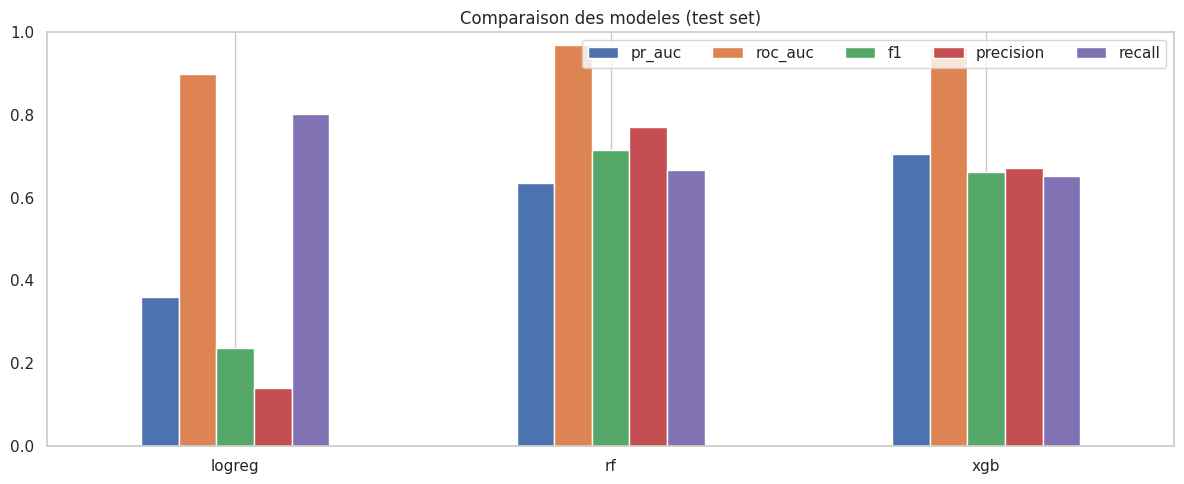

In [7]:
df_res = pd.DataFrame(results).T.round(3)
print(df_res)

df_res.plot(kind="bar", figsize=(12, 5))
plt.title("Comparaison des modeles (test set)")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.legend(loc="upper right", ncol=5)
plt.tight_layout()
plt.show()

## 8. Sélection du meilleur modèle

In [8]:
best_name = df_res["pr_auc"].idxmax()
best_model = models[best_name]
best_metrics = results[best_name]

print(f"Meilleur modele : {best_name}")
print(f"PR-AUC : {best_metrics['pr_auc']:.3f}")
print(f"Seuil grille MSPR (> 0.5) : {'OK' if best_metrics['pr_auc'] > 0.5 else 'ECHEC'}")

Meilleur modele : xgb
PR-AUC : 0.705
Seuil grille MSPR (> 0.5) : OK


## 9. Courbes ROC et Precision-Recall

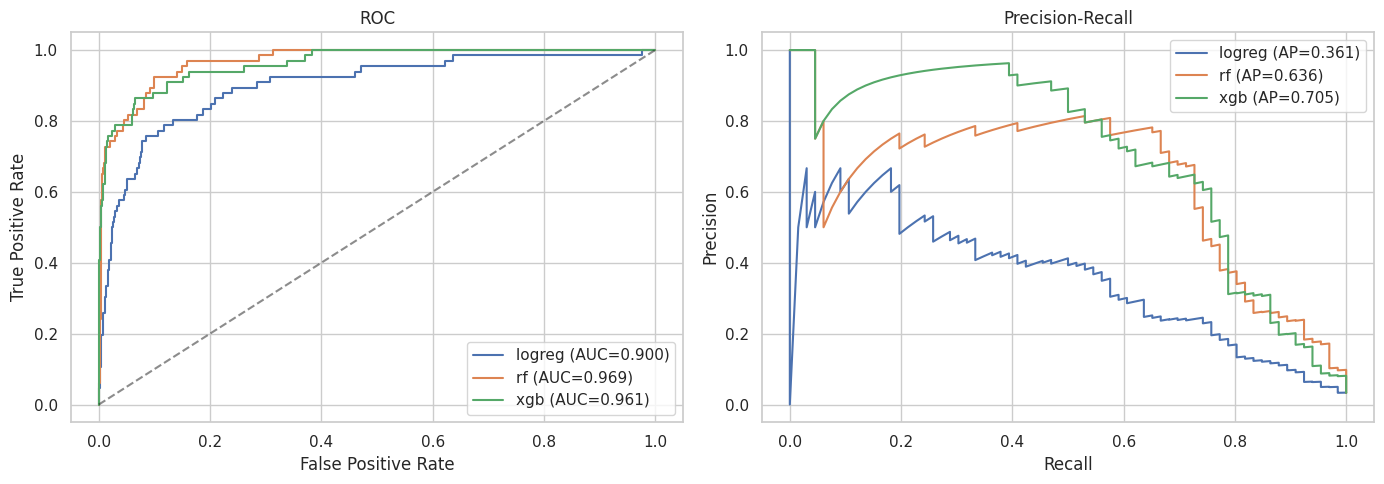

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC ---
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC")
axes[0].legend()

# --- PR ---
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Matrice de confusion du meilleur modèle

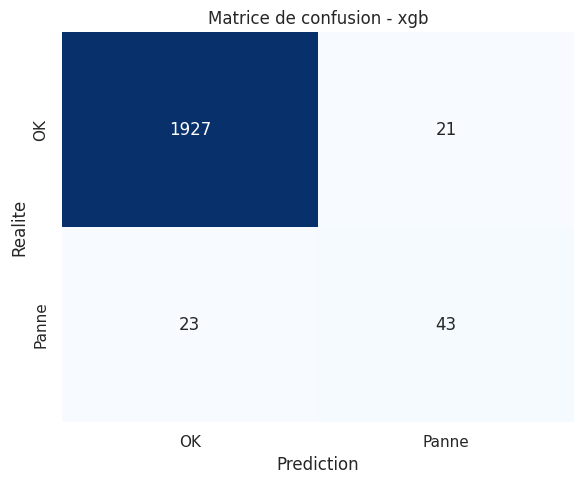


Classification report :
              precision    recall  f1-score   support

          OK       0.99      0.99      0.99      1948
       Panne       0.67      0.65      0.66        66

    accuracy                           0.98      2014
   macro avg       0.83      0.82      0.83      2014
weighted avg       0.98      0.98      0.98      2014



In [10]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["OK", "Panne"], yticklabels=["OK", "Panne"], ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Realite")
ax.set_title(f"Matrice de confusion - {best_name}")
plt.tight_layout()
plt.show()

print("\nClassification report :")
print(classification_report(y_test, y_pred_best, target_names=["OK", "Panne"]))

## 11. Importance des features (si applicable)

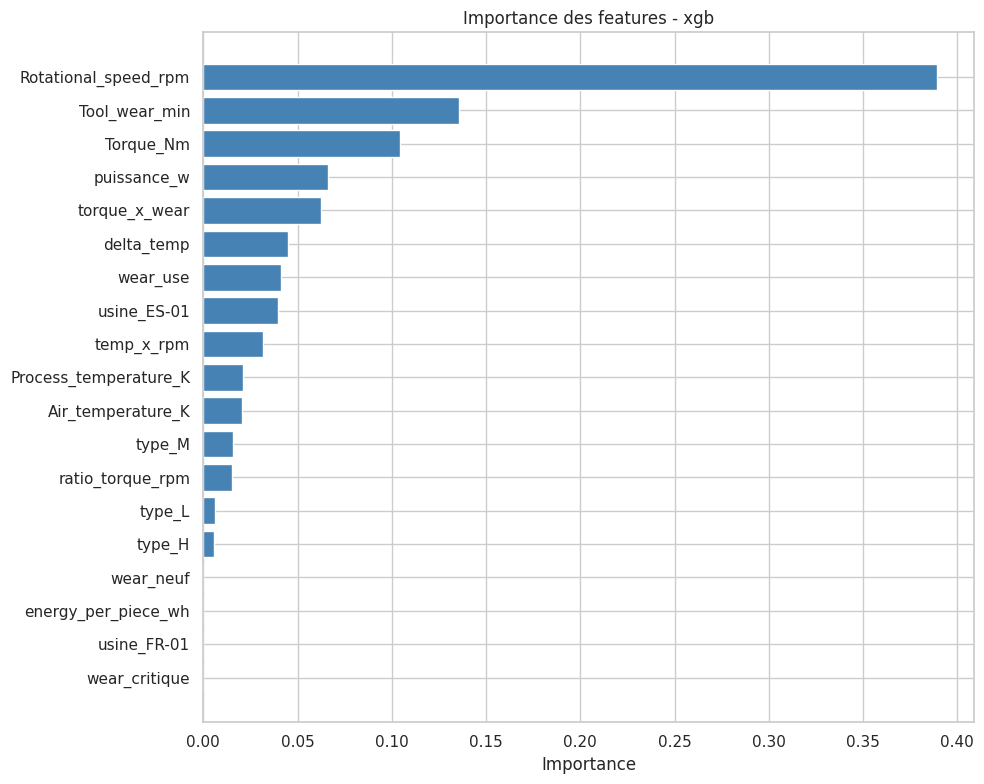


Top 10 features :
              feature  importance
 Rotational_speed_rpm    0.389313
        Tool_wear_min    0.135414
            Torque_Nm    0.104605
          puissance_w    0.066233
        torque_x_wear    0.062446
           delta_temp    0.044685
             wear_use    0.041136
          usine_ES-01    0.039533
           temp_x_rpm    0.031412
Process_temperature_K    0.021176


In [11]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(imp["feature"], imp["importance"], color="steelblue")
    ax.set_title(f"Importance des features - {best_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features :")
    print(imp.tail(10).iloc[::-1].to_string(index=False))
else:
    print("Ce modele ne fournit pas feature_importances_")

## 12. Sauvegarde du meilleur modèle

In [12]:
model_path = GOLD_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

info = {
    "best_model": best_name,
    "metrics": best_metrics,
    "all_results": results,
    "features": list(X.columns),
}
(GOLD_DIR / "best_model_info.json").write_text(json.dumps(info, indent=2))

print(f"Modele sauvegarde : {model_path}")
print(f"Metadata         : {GOLD_DIR / 'best_model_info.json'}")

Modele sauvegarde : /home/romaric420/MSPR/data/gold/best_model.joblib
Metadata         : /home/romaric420/MSPR/data/gold/best_model_info.json


## 13. Interprétation et synthèse

### Résultats

| Modèle | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|---|---|---|---|---|---|
| Logistic Regression | (voir tableau §7) | | | | |
| Random Forest | | | | | |
| XGBoost | | | | | |

### Analyse

- Les arbres boostés (XGBoost) et ensemblistes (RF) dominent la régression logistique sur ce problème → les relations capteurs ↔ panne sont **non-linéaires** (confirmé par les corrélations modérées du notebook 01)
- Les features d'interaction (`torque_x_wear`, `delta_temp`) apportent un signal additionnel
- Le `class_weight="balanced"` (LR/RF) et le `scale_pos_weight` (XGB) compensent efficacement le déséquilibre

### Recommandation pour MECHA

- Déployer le modèle XGBoost dans le système de scoring en production
- Fixer le **seuil opérationnel** à P(panne) > 30% pour déclencher une alerte (à calibrer avec l'équipe qualité)
- Mettre en place un **monitoring de drift** dans MLflow : ré-évaluer le modèle chaque mois sur les nouvelles données

### Grille MSPR couverte

- **C4** : modèle ML avec PR-AUC > 0.5 + interprétation écrite + 3 modèles comparés
- MLflow tracking démontré (tracking URI, expérience, runs, artefacts, log_model)

### Suite

- **Notebook 08** : système d'alertes opérationnelles combinant règles métiers + prédictions du modèle
